In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix

sns.set_theme(style='whitegrid')# nicer default plot styling
np.random.seed(42)
print('Setup complete. NumPy', np.__version__, '| Pandas', pd.__version__)



Setup complete. NumPy 2.0.2 | Pandas 2.2.2


In [ ]:
a = np.arange(6).reshape(2, 3)
print('Array a:\n', a)

# Inspect the array's structure
print('shape :', a.shape)     # (2, 3)  -> 2 rows, 3 cols
print('ndim  :', a.ndim)      # 2       -> number of dimensions
print('dtype :', a.dtype)     # int64   -> data type of elements


Array a:
 [[0 1 2]
 [3 4 5]]
shape : (2, 3)
ndim  : 2
dtype : int64


In [ ]:
row = np.array([10, 20, 30])   # shape (3,)
print('a + row (row added to every row of a):\n', a + row)


a + row (row added to every row of a):
 [[10 21 32]
 [13 24 35]]


In [ ]:
b = np.ones((3, 2), dtype=int)   # shape (3, 2)
print('Matrix product a @ b:\n', a @ b)   # (2,3) @ (3,2) -> (2,2)
print('Column-wise sum  (axis=0):', a.sum(axis=0))
print('Row-wise sum     (axis=1):', a.sum(axis=1))
print('Row-wise mean    (axis=1):', a.mean(axis=1))
print('Index of max per column  :', a.argmax(axis=0))



Matrix product a @ b:
 [[ 3  3]
 [12 12]]
Column-wise sum  (axis=0): [3 5 7]
Row-wise sum     (axis=1): [ 3 12]
Row-wise mean    (axis=1): [1. 4.]
Index of max per column  : [1 1 1]


In [ ]:
pairs = [
    (np.array([1, 0, 1]), np.array([1, 0, 1])),    # pair 1
    (np.array([1, 2, 3]), np.array([3, 2, 1])),    # pair 2
    (np.array([2, 0, 0]), np.array([0, 5, 0])),    # pair 3
]

for i, (u, v) in enumerate(pairs, start=1):
  import numpy as np

pairs = [
    (np.array([1, 0, 1]), np.array([1, 0, 1])),    # pair 1
    (np.array([1, 2, 3]), np.array([3, 2, 1])),    # pair 2
    (np.array([2, 0, 0]), np.array([0, 5, 0])),    # pair 3
]

cosine_values = []

for i, (u, v) in enumerate(pairs, start=1):

    # 1. L1 and L2 norm of u
    l1_norm = np.linalg.norm(u, 1)
    l2_norm = np.linalg.norm(u, 2)

    print(f"Pair {i}")
    print("L1 Norm:", l1_norm)
    print("L2 Norm:", l2_norm)

    # 2. Cosine Similarity
    cosine_similarity = np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))
    cosine_values.append(cosine_similarity)

    print("Cosine Similarity:", round(cosine_similarity, 4))
    print()

# 3. Most similar pair
most_similar = np.argmax(cosine_values) + 1
print("Most Similar Pair =", most_similar)

Pair 1
L1 Norm: 2.0
L2 Norm: 1.4142135623730951
Cosine Similarity: 1.0

Pair 2
L1 Norm: 6.0
L2 Norm: 3.7416573867739413
Cosine Similarity: 0.7143

Pair 3
L1 Norm: 2.0
L2 Norm: 2.0
Cosine Similarity: 0.0

Most Similar Pair = 1


In [ ]:
A = np.array([[2., 1.],
              [1., 3.]])
B = np.array([[1., 0.],
              [4., 2.]])

print('A @ B (matrix multiply):\n', A @ B)
print('A.T   (transpose):\n', A.T)
print('trace(A) = sum of diagonal:', np.trace(A))

A @ B (matrix multiply):
 [[ 6.  2.]
 [13.  6.]]
A.T   (transpose):
 [[2. 1.]
 [1. 3.]]
trace(A) = sum of diagonal: 5.0


In [ ]:
I = np.eye(2)                       # identity: 1s on the diagonal
print('Identity I:\n', I)
# Symmetric: A equals its own transpose
print('A symmetric?', np.allclose(A, A.T))

# Orthogonal: Q.T @ Q == I (a pure rotation/reflection)
theta = np.radians(30)
Q = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
print('Q orthogonal?', np.allclose(Q.T @ Q, I))

Identity I:
 [[1. 0.]
 [0. 1.]]
A symmetric? True
Q orthogonal? True


In [ ]:
M = np.array([[4., 2.],
              [2., 3.]])
P = np.array([[0., -1.],
              [1.,  0.]])   # a 90-degree rotation

# 1. inverse and trace of M
import numpy as np

M = np.array([[4., 2.],
              [2., 3.]])

P = np.array([[0., -1.],
              [1.,  0.]])

# Inverse of M
inverse_M = np.linalg.inv(M)
print("Inverse of M:")
print(inverse_M)

# Trace of M
trace_M = np.trace(M)
print("Trace of M:", trace_M)


# 2. M @ inv(M) == I ?
identity = M @ np.linalg.inv(M)

print(identity)

print(np.allclose(identity, np.eye(2)))


# 3. Is M symmetric? Is P orthogonal?
# Check symmetry
is_symmetric = np.array_equal(M, M.T)
print("Is M Symmetric?", is_symmetric)

# Check orthogonality
is_orthogonal = np.allclose(P.T @ P, np.eye(2))
print("Is P Orthogonal?", is_orthogonal)


Inverse of M:
[[ 0.375 -0.25 ]
 [-0.25   0.5  ]]
Trace of M: 7.0
[[1. 0.]
 [0. 1.]]
True
Is M Symmetric? True
Is P Orthogonal? True


In [ ]:
square = np.array([[0, 1, 1, 0],
                   [0, 0, 1, 1]], dtype=float)

# Scaling matrix: stretch x by 1.5, y by 0.5
S = np.array([[1.5, 0.0],
              [0.0, 0.5]])

# Rotation matrix: rotate by 30 degrees
t = np.radians(30)
R = np.array([[np.cos(t), -np.sin(t)],
              [np.sin(t),  np.cos(t)]])

scaled  = S @ square      # apply scaling
rotated = R @ square      # apply rotation
print('Rotated corners:\n', rotated)

Rotated corners:
 [[ 0.         0.8660254  0.3660254 -0.5      ]
 [ 0.         0.5        1.3660254  0.8660254]]


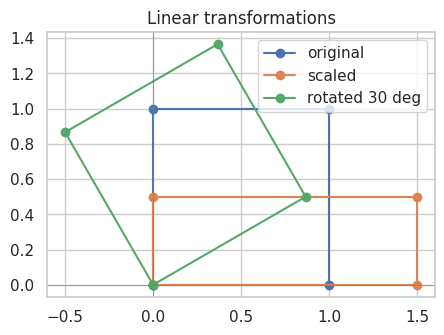

In [ ]:
def close_loop(pts):
    # repeat the first point at the end so the polygon closes
    return np.hstack([pts, pts[:, :1]])

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(*close_loop(square),  marker='o', label='original')
ax.plot(*close_loop(scaled),  marker='o', label='scaled')
ax.plot(*close_loop(rotated), marker='o', label='rotated 30 deg')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_aspect('equal'); ax.legend(); ax.set_title('Linear transformations')
plt.show()

Scaling Matrix:
[[2.  0. ]
 [0.  0.5]]
Rotation Matrix:
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


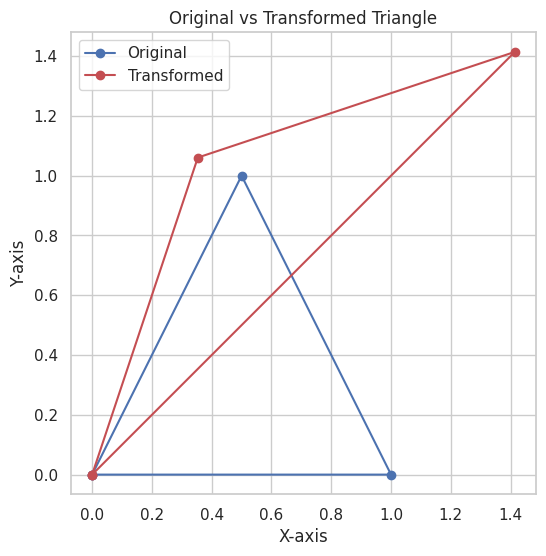

In [ ]:
tri = np.array([[0, 1, 0.5],
                [0, 0, 1.0]])   # 3 corners of a triangle

# 1. Scaling matrix (x*2, y*0.5)
import numpy as np
import matplotlib.pyplot as plt

tri = np.array([[0, 1, 0.5],
                [0, 0, 1.0]])

# Scaling matrix
S = np.array([[2, 0],
              [0, 0.5]])

print("Scaling Matrix:")
print(S)

# 2. Rotation matrix (45 degrees)
theta = np.radians(45)

R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])

print("Rotation Matrix:")
print(R)

# 3. Apply both and plot original vs transformed
# Apply scaling
scaled_tri = S @ tri

# Apply rotation to the scaled triangle
transformed_tri = R @ scaled_tri

# Plot original triangle
plt.figure(figsize=(6,6))

plt.plot(
    np.append(tri[0], tri[0,0]),
    np.append(tri[1], tri[1,0]),
    'bo-', label='Original'
)

# Plot transformed triangle
plt.plot(
    np.append(transformed_tri[0], transformed_tri[0,0]),
    np.append(transformed_tri[1], transformed_tri[1,0]),
    'ro-', label='Transformed'
)

plt.title("Original vs Transformed Triangle")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.grid(True)
plt.axis("equal")
plt.legend()

plt.show()